# Prompt 10 - Pose Estimation Engine

This notebook demonstrates MediaPipe pose landmark inference from a Prompt 9 Video object without calculating joint angles or biomechanical features.


In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.video_processing import Video
from src.pose_estimation import (
    MEDIAPIPE_POSE_LANDMARKS,
    MediaPipePoseEstimator,
    export_annotated_frames,
    landmark_preview,
)


In [2]:
video = Video('reports/video_processing/sample_video.avi')
video.metadata


VideoMetadata(filename='sample_video.avi', path='reports/video_processing/sample_video.avi', duration=2.0, frame_count=24, fps=12.0, width=96, height=64, codec='MJPG')

In [3]:
estimator = MediaPipePoseEstimator('models/pose_landmarker_lite.task')
estimator.load_model()
estimator.backend_name


I0000 00:00:1783628974.260506 41512654 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 8, prefix = pthread-default
I0000 00:00:1783628974.352392 41512654 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1783628974.433249 41512657 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783628974.447605 41512662 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


'mediapipe_tasks'

In [4]:
result = estimator.estimate(video, frame_skip=6)
result.landmarks.shape


(132, 9)

In [5]:
result.landmarks.head(12)


,frame_number,timestamp,landmark_index,landmark_name,x,y,z,visibility,confidence
0,0,0.0,0,nose,NaN,NaN,NaN,NaN,NaN
1,0,0.0,1,left_eye_inner,NaN,NaN,NaN,NaN,NaN
2,0,0.0,2,left_eye,NaN,NaN,NaN,NaN,NaN
3,0,0.0,3,left_eye_outer,NaN,NaN,NaN,NaN,NaN
4,0,0.0,4,right_eye_inner,NaN,NaN,NaN,NaN,NaN
5,0,0.0,5,right_eye,NaN,NaN,NaN,NaN,NaN
6,0,0.0,6,right_eye_outer,NaN,NaN,NaN,NaN,NaN
7,0,0.0,7,left_ear,NaN,NaN,NaN,NaN,NaN
8,0,0.0,8,right_ear,NaN,NaN,NaN,NaN,NaN
9,0,0.0,9,mouth_left,NaN,NaN,NaN,NaN,NaN


In [6]:
result.landmarks.groupby("frame_number").size().head()


frame_number
0     33
6     33
12    33
18    33
dtype: int64

In [7]:
csv_path, json_path = estimator.export_landmarks(result, 'reports/pose_estimation/notebook_landmarks.csv', 'reports/pose_estimation/notebook_landmarks.json')
csv_path, json_path


(PosixPath('reports/pose_estimation/notebook_landmarks.csv'),
 PosixPath('reports/pose_estimation/notebook_landmarks.json'))

In [8]:
paths = export_annotated_frames(video, result, 'reports/pose_estimation/notebook_annotated_frames', max_frames=2)
[str(path) for path in paths]


['reports/pose_estimation/notebook_annotated_frames/annotated_frame_0000.png',
 'reports/pose_estimation/notebook_annotated_frames/annotated_frame_0006.png']

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Pose landmark preview'}>)

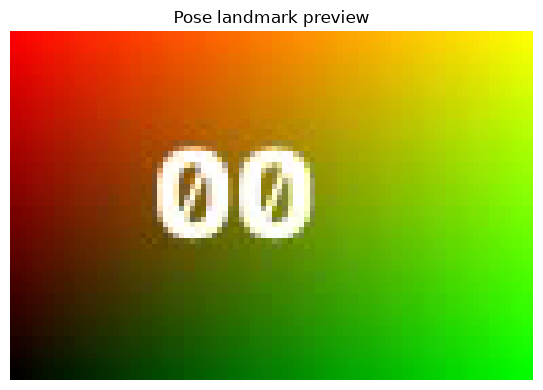

In [9]:
frame0 = video.get_frame(0)
rows0 = result.landmarks[result.landmarks["frame_number"].eq(0)]
landmark_preview(frame0, rows0)
